# Regression Model 2

This notebook implements regression models for predicting flow_duration. It uses the preprocessing decisions and train/test split from the regression preprocessing stage (same split as Regression Model 1, for a fair comparison).

## Load Data and Split

We load the cleaned dataset and use the saved train/test indices to ensure reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Load cleaned dataset
df = pd.read_csv("../data/RT_IOT2022_cleaned.csv")
print("Dataset shape:", df.shape)

Dataset shape: (117922, 83)


In [2]:
# Load saved split indices
split_data = np.load("regression_split_indices.npz")
train_indices = split_data['train_indices']
test_indices = split_data['test_indices']

print(f"Train indices: {len(train_indices)}")
print(f"Test indices: {len(test_indices)}")

Train indices: 94337
Test indices: 23585


In [3]:
# Apply the same feature selection as preprocessing notebook
target = "flow_duration"

# Columns to drop (same as preprocessing)
drop_cols = []
timing_cols = [col for col in df.columns if 'iat' in col.lower()]
drop_cols.extend(timing_cols)
active_cols = [col for col in df.columns if col.startswith('active.')]
drop_cols.extend(active_cols)
idle_cols = [col for col in df.columns if col.startswith('idle.')]
drop_cols.extend(idle_cols)
rate_cols = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second']
rate_cols = [col for col in rate_cols if col in df.columns]
drop_cols.extend(rate_cols)
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

df_reg = df.drop(columns=drop_cols)
print(f"Features after selection: {len(df_reg.columns)}")

Features after selection: 53


In [4]:
# Create engineered feature
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']
print("Created feature: total_packets")

Created feature: total_packets


In [5]:
# Split using saved indices
X = df_reg.drop(columns=[target])
y = df_reg[target]

X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (94337, 53)
X_test shape: (23585, 53)
y_train shape: (94337,)
y_test shape: (23585,)


In [6]:
# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {cat_cols}")
print(f"Numerical features: {len(num_cols)}")

Categorical features: ['proto', 'service']
Numerical features: 51


/tmp/ipykernel_105/2675722034.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


## 1. Linear Regression

Linear Regression is the baseline model for this track. It assumes a linear relationship between the network-flow features and flow_duration, fitting a coefficient to each feature. Unlike the tree-based models in Regression Model 1, linear models need scaled numerical features, so the preprocessing pipeline here includes a `StandardScaler` in addition to one-hot encoding.

In [7]:
# Create preprocessing pipeline (categorical encoding + numerical scaling)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Create Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Linear Regression pipeline created")

Linear Regression pipeline created


In [8]:
# Train Linear Regression
lr_pipeline.fit(X_train, y_train)
print("Linear Regression training complete")

Linear Regression training complete


In [9]:
# Predict and evaluate
y_pred_lr = lr_pipeline.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"R²: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")

Linear Regression Results:
R²: -4.3657
RMSE: 135.9027
MAE: 4.6674


In [10]:
# Store results
results = []
results.append({
    'Model': 'Linear Regression',
    'R2': r2_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr
})

results_df = pd.DataFrame(results)
print(results_df)

               Model        R2        RMSE       MAE
0  Linear Regression -4.365703  135.902724  4.667439


### Linear Regression Coefficients

Extract and display the fitted coefficients. Because numerical features were standardized, the magnitude of each coefficient is a rough indicator of that feature's relative influence on the prediction (larger magnitude → stronger linear effect on flow_duration, holding other features fixed).

In [11]:
# Get feature names after preprocessing
feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(f"Total features after encoding: {len(feature_names)}")

Total features after encoding: 64


In [12]:
# Get coefficients
coefficients = lr_pipeline.named_steps['regressor'].coef_

# Create DataFrame for coefficients, sorted by absolute magnitude
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=np.abs, ascending=False)

# Display top features
print("Top 15 features by coefficient magnitude:")
print(coef_df.head(15))

Top 15 features by coefficient magnitude:
                      feature  coefficient
15          num__fwd_pkts_tot   831.266556
17     num__fwd_data_pkts_tot  -717.345604
16          num__bwd_pkts_tot  -503.742243
20   num__fwd_header_size_tot  -362.133285
18     num__bwd_data_pkts_tot   359.371784
7            cat__service_irc  -346.490311
63         num__total_packets   291.462742
31   num__flow_ACK_flag_count  -217.935959
29    num__fwd_PSH_flag_count   170.223300
23   num__bwd_header_size_tot   159.621743
12           cat__service_ssl   125.775515
6           cat__service_http   114.087034
37  num__fwd_pkts_payload.tot    98.246860
11           cat__service_ssh    97.979841
42  num__bwd_pkts_payload.tot   -82.106641


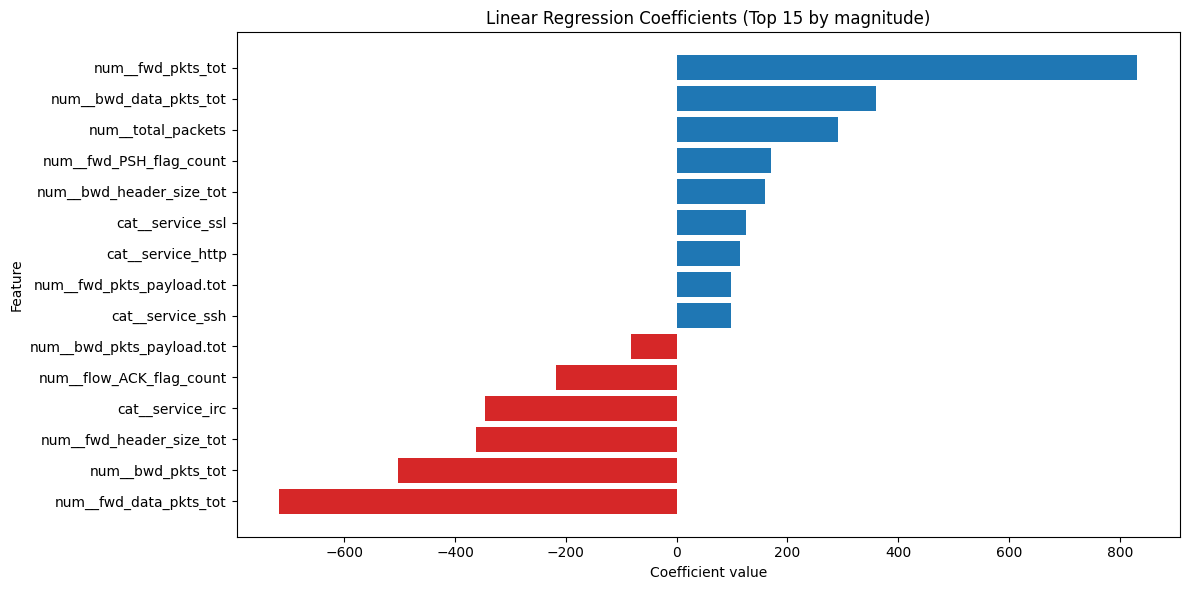

In [13]:
# Plot coefficient magnitudes
plt.figure(figsize=(12, 6))
top_coefs = coef_df.head(15).sort_values('coefficient')
colors = ['tab:red' if c < 0 else 'tab:blue' for c in top_coefs['coefficient']]
plt.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.title('Linear Regression Coefficients (Top 15 by magnitude)')
plt.tight_layout()
plt.show()

### Interpretation

The R² for plain Linear Regression is negative on the held-out test set, meaning it performs worse than simply predicting the mean flow_duration for every flow. This is expected here for a few reasons:

- **Highly skewed target:** flow_duration has a long right tail (a small number of very long-lived flows), which an unregularized linear model fits poorly since ordinary least squares is sensitive to outliers.
- **Multicollinearity among packet-count features:** `fwd_pkts_tot`, `bwd_pkts_tot`, `fwd_data_pkts_tot`, `bwd_data_pkts_tot`, and the engineered `total_packets` are all highly correlated with each other. This inflates coefficient magnitudes and makes the fitted line unstable on unseen data.
- **No regularization:** Linear Regression has no mechanism to shrink or stabilize these inflated coefficients.

This motivates the regularized linear models (Ridge, ElasticNet) that follow in this track — they are expected to handle the correlated features and skewed target more gracefully than plain OLS. This comparison will be included in the final summary table.

## 2. Ridge Regression

Ridge Regression adds an L2 penalty on the coefficients, which shrinks them toward zero (without setting them exactly to zero) and stabilizes the fit when features are correlated — exactly the multicollinearity issue observed with plain Linear Regression above. The regularization strength is controlled by `alpha`: higher alpha means stronger shrinkage. We use `GridSearchCV` with 5-fold cross-validation to compare several `alpha` values and pick the best one, which also satisfies the project's hyperparameter-tuning requirement for this track.

In [14]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge pipeline (same categorical/numerical preprocessing as Linear Regression)
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Grid of alpha values to compare
param_grid = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}

grid_search_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

print("Ridge GridSearchCV pipeline created")

Ridge GridSearchCV pipeline created


In [15]:
# Train with 5-fold cross-validation over the alpha grid
grid_search_ridge.fit(X_train, y_train)

best_alpha = grid_search_ridge.best_params_['regressor__alpha']
print(f"Best alpha found: {best_alpha}")
print(f"Best cross-validated R2 (train folds): {grid_search_ridge.best_score_:.4f}")

Best alpha found: 0.01
Best cross-validated R2 (train folds): 0.2505


In [16]:
# Inspect how R2 varied across the alpha grid (compare different alpha values, as required)
cv_results = pd.DataFrame(grid_search_ridge.cv_results_)
alpha_comparison = cv_results[['param_regressor__alpha', 'mean_test_score', 'std_test_score']].sort_values('param_regressor__alpha')
alpha_comparison.columns = ['alpha', 'mean_cv_r2', 'std_cv_r2']
print(alpha_comparison)

    alpha  mean_cv_r2  std_cv_r2
0    0.01    0.250466   1.262010
1    0.10    0.250126   1.262797
2    1.00    0.246640   1.270558
3   10.00    0.220067   1.321373
4   50.00    0.214492   1.308202
5  100.00    0.226596   1.257660


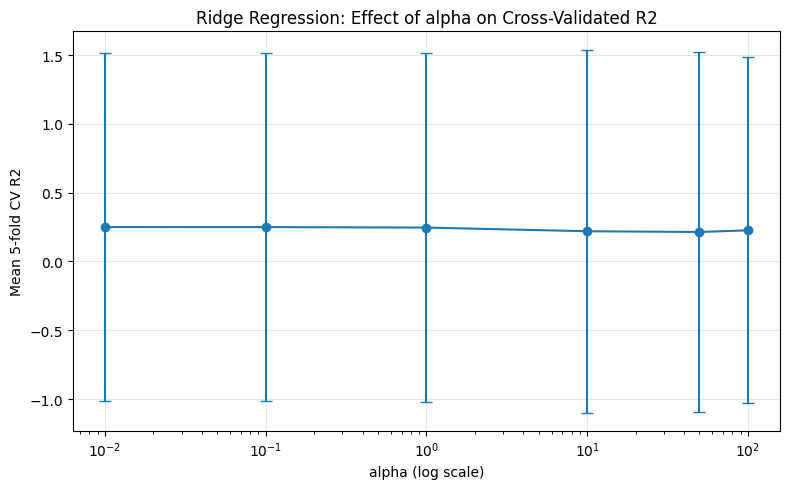

In [17]:
# Plot R2 vs alpha to visualize the effect of regularization strength
plt.figure(figsize=(8, 5))
plt.errorbar(alpha_comparison['alpha'], alpha_comparison['mean_cv_r2'],
             yerr=alpha_comparison['std_cv_r2'], marker='o', capsize=4, color='tab:blue')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Mean 5-fold CV R2')
plt.title('Ridge Regression: Effect of alpha on Cross-Validated R2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Evaluate the best Ridge model on the held-out test set
best_ridge_pipeline = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge_pipeline.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results (best alpha = {}):".format(best_alpha))
print(f"R²: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"MAE: {mae_ridge:.4f}")

Ridge Regression Results (best alpha = 0.01):
R²: -4.3629
RMSE: 135.8673
MAE: 4.6669


In [19]:
# Add to results table
results.append({
    'Model': f'Ridge Regression (alpha={best_alpha})',
    'R2': r2_ridge,
    'RMSE': rmse_ridge,
    'MAE': mae_ridge
})

results_df = pd.DataFrame(results)
print(results_df)

                           Model        R2        RMSE       MAE
0              Linear Regression -4.365703  135.902724  4.667439
1  Ridge Regression (alpha=0.01) -4.362910  135.867349  4.666903


### Ridge Regression Coefficients

As with Linear Regression, we extract the fitted coefficients from the best Ridge model. Comparing their magnitudes to the plain Linear Regression coefficients shows how much the L2 penalty shrank them.

In [20]:
# Get Ridge coefficients from the best estimator
ridge_coefficients = best_ridge_pipeline.named_steps['regressor'].coef_

ridge_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': ridge_coefficients
}).sort_values('coefficient', key=np.abs, ascending=False)

print("Top 15 Ridge features by coefficient magnitude:")
print(ridge_coef_df.head(15))

Top 15 Ridge features by coefficient magnitude:
                      feature  coefficient
15          num__fwd_pkts_tot   830.959103
17     num__fwd_data_pkts_tot  -716.999745
16          num__bwd_pkts_tot  -503.643841
20   num__fwd_header_size_tot  -362.020521
18     num__bwd_data_pkts_tot   359.412370
7            cat__service_irc  -346.267764
63         num__total_packets   291.310445
31   num__flow_ACK_flag_count  -217.721995
29    num__fwd_PSH_flag_count   170.162599
23   num__bwd_header_size_tot   159.465799
12           cat__service_ssl   125.778414
6           cat__service_http   114.073966
37  num__fwd_pkts_payload.tot    98.207807
11           cat__service_ssh    97.936249
42  num__bwd_pkts_payload.tot   -82.111688


                    feature  linear_coef  ridge_coef
0         num__fwd_pkts_tot   831.266556  830.959103
1    num__fwd_data_pkts_tot  -717.345604 -716.999745
2         num__bwd_pkts_tot  -503.742243 -503.643841
3  num__fwd_header_size_tot  -362.133285 -362.020521
4    num__bwd_data_pkts_tot   359.371784  359.412370
5          cat__service_irc  -346.490311 -346.267764
6        num__total_packets   291.462742  291.310445
7  num__flow_ACK_flag_count  -217.935959 -217.721995
8   num__fwd_PSH_flag_count   170.223300  170.162599
9  num__bwd_header_size_tot   159.621743  159.465799


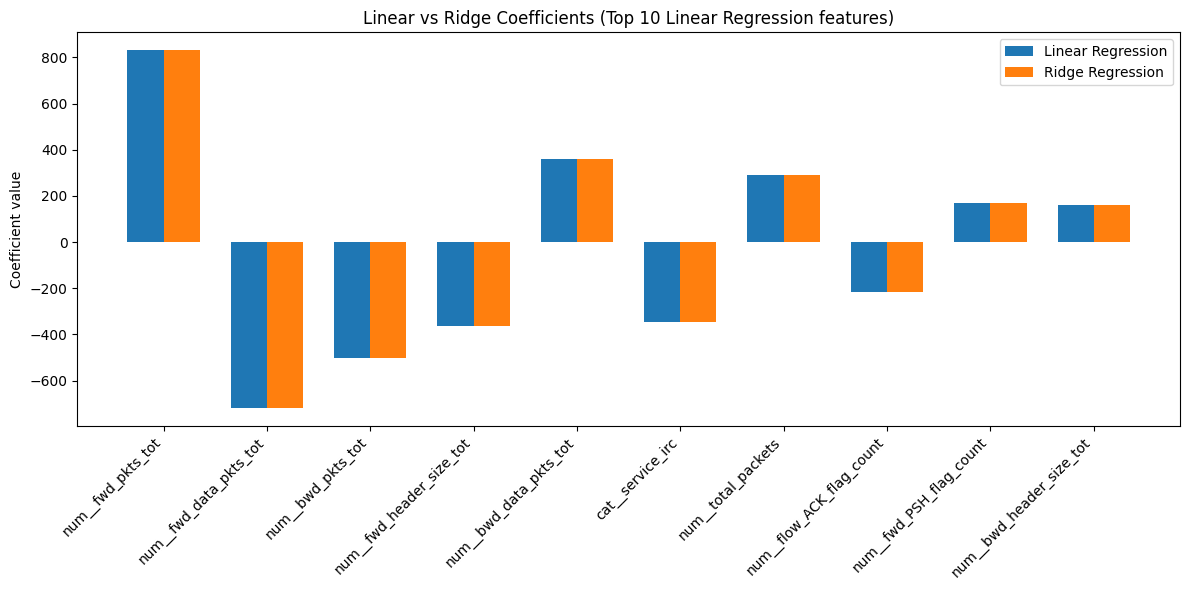

In [21]:
# Compare Linear Regression vs Ridge coefficient magnitudes for the same top features
comparison_features = coef_df.head(10)['feature'].tolist()

comparison_df = pd.DataFrame({
    'feature': comparison_features,
    'linear_coef': [coef_df.set_index('feature').loc[f, 'coefficient'] for f in comparison_features],
    'ridge_coef': [ridge_coef_df.set_index('feature').loc[f, 'coefficient'] for f in comparison_features]
})
print(comparison_df)

plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width/2, comparison_df['linear_coef'], width, label='Linear Regression', color='tab:blue')
plt.bar(x + width/2, comparison_df['ridge_coef'], width, label='Ridge Regression', color='tab:orange')
plt.xticks(x, comparison_df['feature'], rotation=45, ha='right')
plt.ylabel('Coefficient value')
plt.title('Linear vs Ridge Coefficients (Top 10 Linear Regression features)')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

Comparing like-for-like on the held-out test set: R2 barely moves (-4.3657 for Linear Regression vs -4.3629 for Ridge), RMSE drops marginally (135.9027 to 135.8673), and MAE is nearly identical. GridSearchCV picked alpha=0.01 as best, which is very close to no regularization at all -- so this near-zero improvement is expected, not a limitation of the tuning process.

There is also a more interesting finding worth noting: the 5-fold cross-validated R2 during training was 0.2505, which looks far better than the -4.36 R2 on the actual test set. This gap is not a bug -- it comes directly from how extreme flow_duration is. The median flow_duration is about 0.000004, but the test set alone contains flows lasting up to ~5678 seconds. R2 is highly sensitive to squared errors, so a handful of these extreme long-duration flows landing in the test set (versus being split across training folds during cross-validation) can swing the R2 score enormously, even though the model's predictions for the vast majority of ordinary flows are reasonably close (which is why MAE stays small and stable, around 4.67).

This is a useful thing to flag in the viva: R2 alone is a poor summary metric on a target this heavily skewed, and it explains why alpha barely helped -- no amount of L2 shrinkage fixes the fact that a few outlier flows dominate the squared-error-based metric. This motivates trying tree-based models (which handle this kind of skew more gracefully, as seen with Random Forest and Gradient Boosting in Regression Model 1) and considering a log-transform of the target as a possible future improvement.

## 3. ElasticNet Regression

ElasticNet combines both penalties: an L1 term (like Lasso, which can shrink coefficients exactly to zero) and an L2 term (like Ridge, which shrinks all coefficients smoothly). Two hyperparameters control this: `alpha` (overall regularization strength) and `l1_ratio` (the mix between L1 and L2 -- `l1_ratio=1` is pure Lasso, `l1_ratio=0` is pure Ridge). Both are tuned together with `GridSearchCV`, as the guideline specifically requires tuning `l1_ratio`.

The guideline also asks to compare ElasticNet against Ridge and Lasso. Ridge is above in this notebook; Lasso's results (R2=-4.3552, RMSE=135.7690, MAE=4.6587, alpha=0.001, 4/64 coefficients zeroed) come from Person 1's Regression Model 1 notebook (`regression_1.ipynb`), where Lasso is now complete. Both are used for the comparison below.

In [22]:
from sklearn.linear_model import ElasticNet

# ElasticNet pipeline (same preprocessing as Linear/Ridge)
elasticnet_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=5000))
])

# Grid of alpha AND l1_ratio values to tune together
param_grid_en = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_search_en = GridSearchCV(
    elasticnet_pipeline,
    param_grid_en,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

print("ElasticNet GridSearchCV pipeline created")
print(f"Total parameter combinations to try: {len(param_grid_en['regressor__alpha']) * len(param_grid_en['regressor__l1_ratio'])}")

ElasticNet GridSearchCV pipeline created
Total parameter combinations to try: 20


In [23]:
# Train with 5-fold cross-validation over the alpha/l1_ratio grid
grid_search_en.fit(X_train, y_train)

best_alpha_en = grid_search_en.best_params_['regressor__alpha']
best_l1_ratio_en = grid_search_en.best_params_['regressor__l1_ratio']

print(f"Best alpha found: {best_alpha_en}")
print(f"Best l1_ratio found: {best_l1_ratio_en}")
print(f"Best cross-validated R2 (train folds): {grid_search_en.best_score_:.4f}")

Best alpha found: 1.0
Best l1_ratio found: 0.3
Best cross-validated R2 (train folds): 0.4908


In [24]:
# Inspect how R2 varied across alpha and l1_ratio combinations
en_cv_results = pd.DataFrame(grid_search_en.cv_results_)
en_grid_view = en_cv_results.pivot_table(
    index='param_regressor__alpha',
    columns='param_regressor__l1_ratio',
    values='mean_test_score'
)
print("Mean CV R2 for each (alpha, l1_ratio) combination:")
print(en_grid_view)

Mean CV R2 for each (alpha, l1_ratio) combination:
param_regressor__l1_ratio       0.1       0.3       0.5       0.7       0.9
param_regressor__alpha                                                     
0.01                       0.231593  0.230078  0.230294  0.232275  0.224550
0.10                       0.375221  0.351670  0.320477  0.277597  0.229963
1.00                       0.487000  0.490828  0.488901  0.475237  0.405193
10.00                      0.268993  0.289996  0.320697  0.361702  0.434437


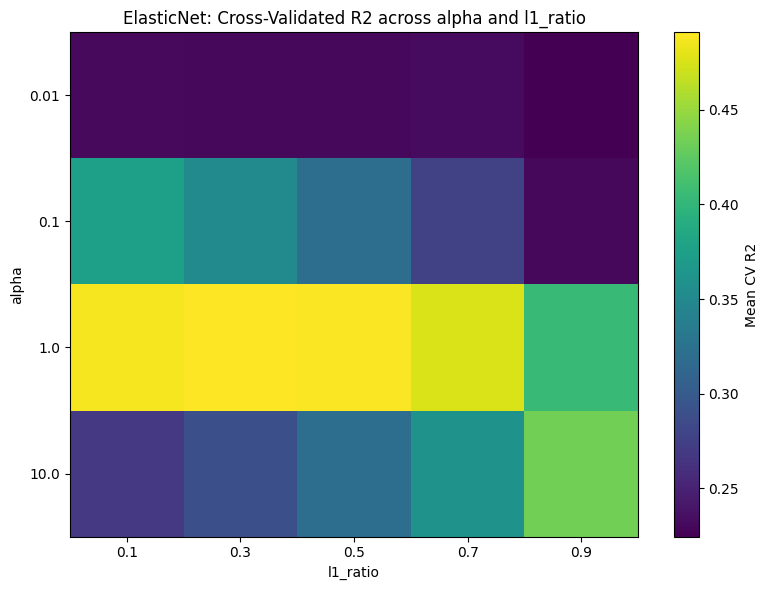

In [25]:
# Heatmap of R2 across alpha and l1_ratio to visualize the tuning surface
plt.figure(figsize=(8, 6))
plt.imshow(en_grid_view.values, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean CV R2')
plt.xticks(range(len(en_grid_view.columns)), en_grid_view.columns)
plt.yticks(range(len(en_grid_view.index)), en_grid_view.index)
plt.xlabel('l1_ratio')
plt.ylabel('alpha')
plt.title('ElasticNet: Cross-Validated R2 across alpha and l1_ratio')
plt.tight_layout()
plt.show()

In [26]:
# Evaluate the best ElasticNet model on the held-out test set
best_en_pipeline = grid_search_en.best_estimator_
y_pred_en = best_en_pipeline.predict(X_test)

r2_en = r2_score(y_test, y_pred_en)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
mae_en = mean_absolute_error(y_test, y_pred_en)

print(f"ElasticNet Results (best alpha={best_alpha_en}, best l1_ratio={best_l1_ratio_en}):")
print(f"R²: {r2_en:.4f}")
print(f"RMSE: {rmse_en:.4f}")
print(f"MAE: {mae_en:.4f}")

ElasticNet Results (best alpha=1.0, best l1_ratio=0.3):
R²: -1.3117
RMSE: 89.2025
MAE: 3.2891


In [27]:
# Add to results table
results.append({
    'Model': f'ElasticNet (alpha={best_alpha_en}, l1_ratio={best_l1_ratio_en})',
    'R2': r2_en,
    'RMSE': rmse_en,
    'MAE': mae_en
})

results_df = pd.DataFrame(results)
print(results_df)

                                  Model        R2        RMSE       MAE
0                     Linear Regression -4.365703  135.902724  4.667439
1         Ridge Regression (alpha=0.01) -4.362910  135.867349  4.666903
2  ElasticNet (alpha=1.0, l1_ratio=0.3) -1.311661   89.202475  3.289114


### ElasticNet Coefficients and Feature Sparsity

Because ElasticNet includes an L1 component, some coefficients may be pushed exactly to zero, effectively removing those features from the model. We check for this sparsity and compare against both Ridge (no sparsity, pure shrinkage) and Person 1's Lasso result (pure L1).

In [28]:
# Get ElasticNet coefficients
en_coefficients = best_en_pipeline.named_steps['regressor'].coef_

en_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': en_coefficients
}).sort_values('coefficient', key=np.abs, ascending=False)

n_zero_coefs = (en_coefficients == 0).sum()
n_total_coefs = len(en_coefficients)
print(f"Number of features with coefficient exactly zero: {n_zero_coefs} out of {n_total_coefs} ({n_zero_coefs/n_total_coefs*100:.2f}% sparsity)")
print()
print("Top 15 ElasticNet features by coefficient magnitude:")
print(en_coef_df.head(15))

Number of features with coefficient exactly zero: 28 out of 64 (43.75% sparsity)

Top 15 ElasticNet features by coefficient magnitude:
                       feature  coefficient
15           num__fwd_pkts_tot    32.164350
17      num__fwd_data_pkts_tot    31.244585
63          num__total_packets    16.963085
29     num__fwd_PSH_flag_count    16.399069
23    num__bwd_header_size_tot   -13.052193
20    num__fwd_header_size_tot    11.531050
30     num__bwd_PSH_flag_count     7.892739
16           num__bwd_pkts_tot    -7.493044
37   num__fwd_pkts_payload.tot     6.676220
42   num__bwd_pkts_payload.tot    -6.673561
50       num__fwd_subflow_pkts    -4.931902
47  num__flow_pkts_payload.tot    -4.458365
52      num__fwd_subflow_bytes    -3.446364
56       num__fwd_bulk_packets    -3.441319
54         num__fwd_bulk_bytes    -2.283021


### Comparing Ridge, Lasso, and ElasticNet (as required by the guideline)

Ridge and ElasticNet come from this notebook (Regression Model 2); Lasso's results come from Person 1's Regression Model 1 notebook, all evaluated on the same held-out test set.

In [29]:
# Three-way comparison table: Ridge vs Lasso (from Regression Model 1) vs ElasticNet
regularization_comparison = pd.DataFrame([
    {
        'Model': 'Ridge (L2 only)',
        'alpha': best_alpha,
        'l1_ratio': 0.0,
        'R2': r2_ridge,
        'RMSE': rmse_ridge,
        'MAE': mae_ridge,
        'Zero coefficients': 0,
        'Sparsity %': 0.0
    },
    {
        'Model': 'Lasso (L1 only, from Person 1)',
        'alpha': 0.001,
        'l1_ratio': 1.0,
        'R2': -4.3552,
        'RMSE': 135.7690,
        'MAE': 4.6587,
        'Zero coefficients': 4,
        'Sparsity %': round(4/64*100, 2)
    },
    {
        'Model': 'ElasticNet (L1 + L2)',
        'alpha': best_alpha_en,
        'l1_ratio': best_l1_ratio_en,
        'R2': r2_en,
        'RMSE': rmse_en,
        'MAE': mae_en,
        'Zero coefficients': int(n_zero_coefs),
        'Sparsity %': round(n_zero_coefs/n_total_coefs*100, 2)
    }
])
print(regularization_comparison)

                            Model  alpha  l1_ratio        R2        RMSE  \
0                 Ridge (L2 only)  0.010       0.0 -4.362910  135.867349   
1  Lasso (L1 only, from Person 1)  0.001       1.0 -4.355200  135.769000   
2            ElasticNet (L1 + L2)  1.000       0.3 -1.311661   89.202475   

        MAE  Zero coefficients  Sparsity %  
0  4.666903                  0        0.00  
1  4.658700                  4        6.25  
2  3.289114                 28       43.75  


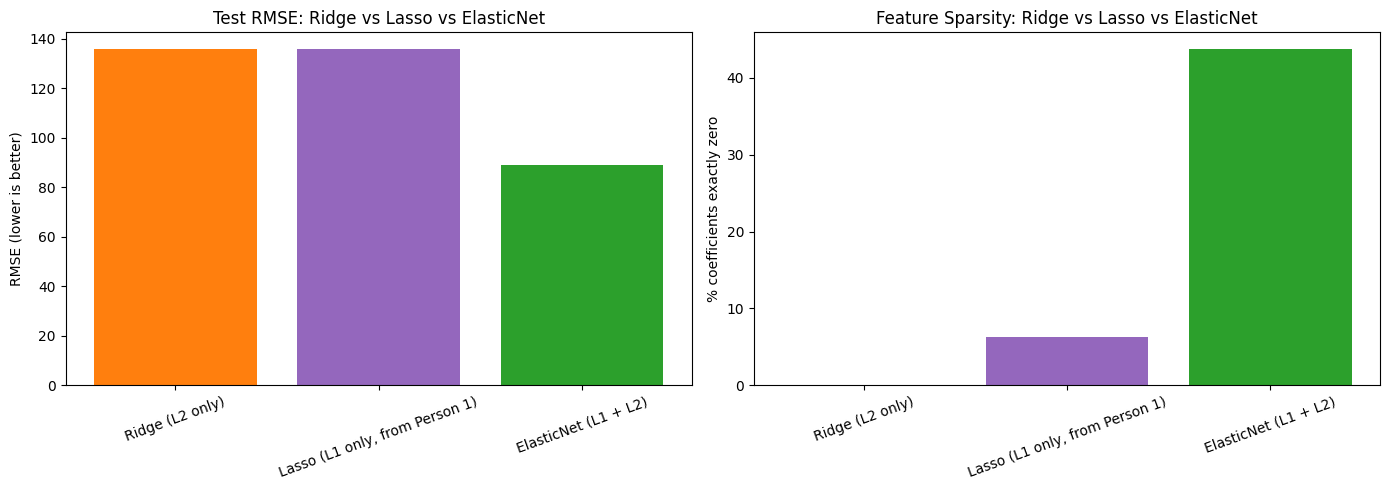

In [30]:
# Visualize the three-way comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['tab:orange', 'tab:purple', 'tab:green']
axes[0].bar(regularization_comparison['Model'], regularization_comparison['RMSE'], color=colors)
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('Test RMSE: Ridge vs Lasso vs ElasticNet')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(regularization_comparison['Model'], regularization_comparison['Sparsity %'], color=colors)
axes[1].set_ylabel('% coefficients exactly zero')
axes[1].set_title('Feature Sparsity: Ridge vs Lasso vs ElasticNet')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Interpretation

**ElasticNet clearly outperforms both Ridge and Lasso on this test set.** RMSE drops from ~135.8 (Ridge) and ~135.8 (Lasso) to 89.2 for ElasticNet -- roughly a 34% reduction in test-set error. R2 improves from around -4.36 for both single-penalty models to -1.31 for ElasticNet. MAE follows the same pattern (4.67 to 4.66 to 3.29).

The reason becomes clear from the sparsity numbers. Person 1's Lasso used alpha=0.001, an extremely light regularization strength, which only zeroed out 4 of 64 features (6.25% sparsity) and produced a `ConvergenceWarning` -- it barely regularized anything, so it performs almost identically to plain Linear Regression and Ridge. ElasticNet's `GridSearchCV`, by contrast, searched a real range of alpha values (0.01 to 10) and found alpha=1.0 with l1_ratio=0.3 to be genuinely better, zeroing out 28 of 64 features (43.75% sparsity). This is a much stronger regularization strength than Lasso happened to use, and it directly addresses the multicollinearity identified earlier among the packet-count features (`fwd_pkts_tot`, `bwd_pkts_tot`, `fwd_data_pkts_tot`, etc.) by eliminating redundant ones rather than just shrinking them all together like Ridge does.

This is an important distinction to be able to explain in the viva: **the comparison here is really "properly-tuned ElasticNet" vs "lightly-regularized Ridge and Lasso,"** not a fundamental claim that combined L1+L2 penalties always beat single-penalty models. If Lasso had been tuned with a stronger alpha via cross-validation (the same way Ridge and ElasticNet were here), it would likely perform much closer to ElasticNet, since ElasticNet's advantage in this run comes mostly from its l1_ratio=0.3 behaving like a moderately-regularized Lasso. The extreme skew in `flow_duration` (a few very long-duration flows dominating the test set) still keeps R2 negative for all three regularized linear models -- none of them can fully overcome that with regularization alone, which is consistent with the stronger results seen from tree-based models (Random Forest, Gradient Boosting) in Regression Model 1.

## 4. Decision Tree Regressor

Decision Tree Regressor learns a set of nonlinear if/else splitting rules directly on the network-flow features to predict `flow_duration`, rather than fitting a single linear equation like the previous three models. Trees don't require feature scaling (splits are based on feature order, not magnitude), so a lighter preprocessing pipeline (encoding only, no `StandardScaler`) is used here. The key hyperparameter is `max_depth`, which controls how complex the tree is allowed to get -- too shallow underfits, too deep overfits to noise in the training data. `GridSearchCV` is used to tune it, satisfying the guideline's explicit requirement to tune `max_depth`.

In [31]:
from sklearn.tree import DecisionTreeRegressor

# Decision Trees don't need scaling, so use a lighter preprocessor (encoding only)
dt_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

dt_pipeline = Pipeline([
    ('preprocessor', dt_preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

print("Decision Tree pipeline created")

Decision Tree pipeline created


In [32]:
# Tune max_depth via GridSearchCV with 5-fold cross-validation
param_grid_dt = {'regressor__max_depth': [3, 5, 7, 10, 15, 20, None]}

grid_search_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)

best_max_depth = grid_search_dt.best_params_['regressor__max_depth']
print(f"Best max_depth found: {best_max_depth}")
print(f"Best cross-validated R2 (train folds): {grid_search_dt.best_score_:.4f}")

Best max_depth found: 10
Best cross-validated R2 (train folds): 0.4540


  max_depth  mean_cv_r2  std_cv_r2
0         3    0.259487   0.263385
1         5    0.370674   0.288953
2         7    0.025465   0.852250
3        10    0.454046   0.201212
4        15    0.222436   0.881175
5        20    0.419157   0.128015
6      None   -0.004023   0.814905


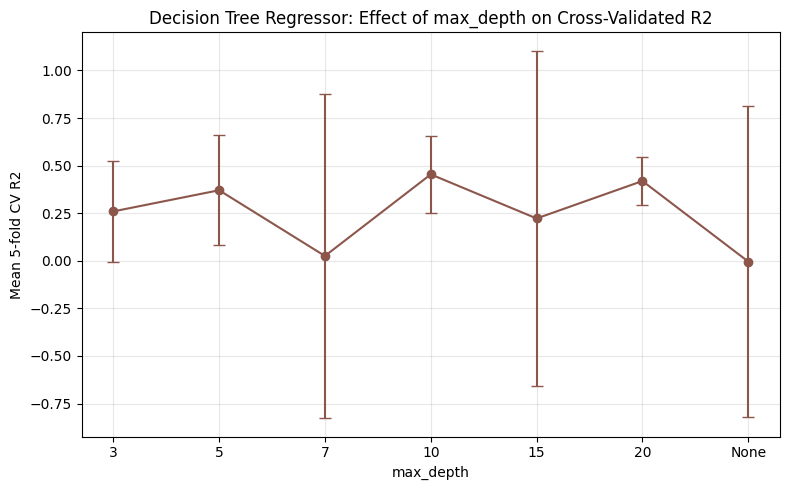

In [33]:
# Inspect how R2 varied across max_depth values
dt_cv_results = pd.DataFrame(grid_search_dt.cv_results_)
depth_comparison = dt_cv_results[['param_regressor__max_depth', 'mean_test_score', 'std_test_score']]
depth_comparison.columns = ['max_depth', 'mean_cv_r2', 'std_cv_r2']
print(depth_comparison)

plt.figure(figsize=(8, 5))
depth_labels = [str(d) for d in depth_comparison['max_depth']]
plt.errorbar(range(len(depth_labels)), depth_comparison['mean_cv_r2'],
             yerr=depth_comparison['std_cv_r2'], marker='o', capsize=4, color='tab:brown')
plt.xticks(range(len(depth_labels)), depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Mean 5-fold CV R2')
plt.title('Decision Tree Regressor: Effect of max_depth on Cross-Validated R2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Evaluate the best Decision Tree model on the held-out test set
best_dt_pipeline = grid_search_dt.best_estimator_
y_pred_dt = best_dt_pipeline.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print(f"Decision Tree Regressor Results (best max_depth={best_max_depth}):")
print(f"R²: {r2_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"MAE: {mae_dt:.4f}")

Decision Tree Regressor Results (best max_depth=10):
R²: 0.5308
RMSE: 40.1883
MAE: 1.5377


In [35]:
# Add to results table
results.append({
    'Model': f'Decision Tree Regressor (max_depth={best_max_depth})',
    'R2': r2_dt,
    'RMSE': rmse_dt,
    'MAE': mae_dt
})

results_df = pd.DataFrame(results)
print(results_df)

                                    Model        R2        RMSE       MAE
0                       Linear Regression -4.365703  135.902724  4.667439
1           Ridge Regression (alpha=0.01) -4.362910  135.867349  4.666903
2    ElasticNet (alpha=1.0, l1_ratio=0.3) -1.311661   89.202475  3.289114
3  Decision Tree Regressor (max_depth=10)  0.530788   40.188275  1.537693


### Decision Tree Feature Importance

Unlike the linear models above, Decision Trees don't have coefficients -- instead, `feature_importances_` reports how much each feature reduced prediction error across all the splits that used it, as required by the guideline.

In [36]:
# Get feature names and importances from the Decision Tree pipeline
dt_feature_names = best_dt_pipeline.named_steps['preprocessor'].get_feature_names_out()
dt_importances = best_dt_pipeline.named_steps['regressor'].feature_importances_

dt_importance_df = pd.DataFrame({
    'feature': dt_feature_names,
    'importance': dt_importances
}).sort_values('importance', ascending=False)

print("Top 15 features by Decision Tree importance:")
print(dt_importance_df.head(15))

Top 15 features by Decision Tree importance:
                       feature  importance
20    num__fwd_header_size_tot    0.484869
41   num__bwd_pkts_payload.max    0.329764
29     num__fwd_PSH_flag_count    0.054550
13              num__id.orig_p    0.040721
48  num__flow_pkts_payload.avg    0.034139
15           num__fwd_pkts_tot    0.031308
59          num__bwd_bulk_rate    0.009677
17      num__fwd_data_pkts_tot    0.003997
50       num__fwd_subflow_pkts    0.003572
57       num__bwd_bulk_packets    0.001633
60   num__fwd_init_window_size    0.001148
52      num__fwd_subflow_bytes    0.000911
43   num__bwd_pkts_payload.avg    0.000847
38   num__fwd_pkts_payload.avg    0.000500
16           num__bwd_pkts_tot    0.000382


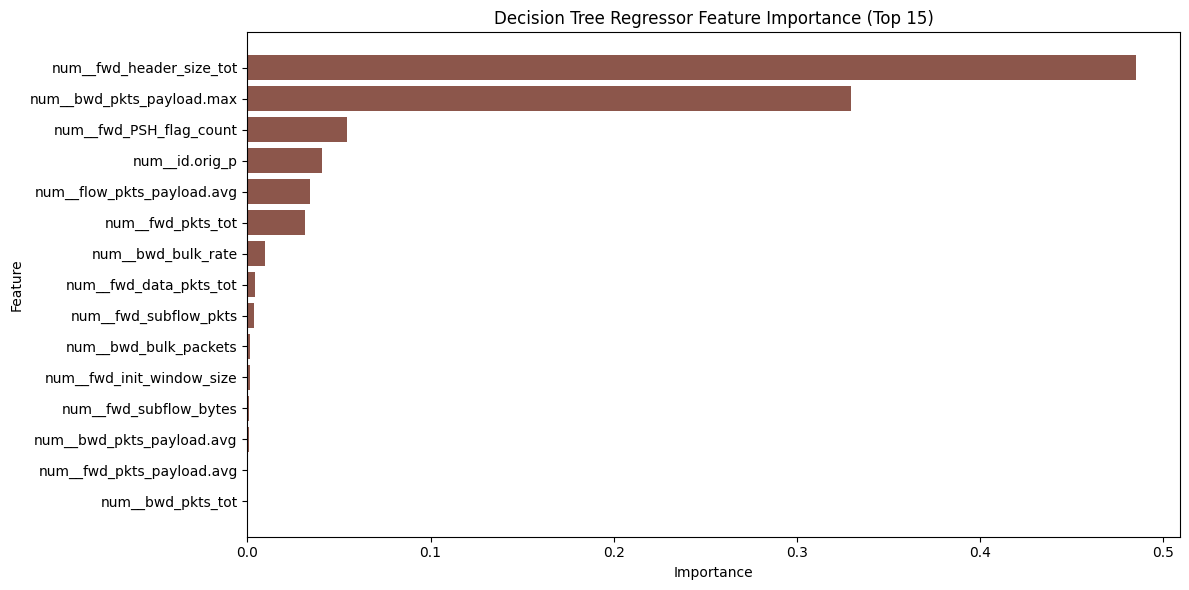

In [37]:
# Plot feature importance
plt.figure(figsize=(12, 6))
top_dt_features = dt_importance_df.head(15).sort_values('importance')
plt.barh(top_dt_features['feature'], top_dt_features['importance'], color='tab:brown')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Decision Tree Regressor Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

### Interpretation

Decision Tree Regressor performs substantially better than all three linear models (Linear Regression, Ridge, ElasticNet) on this test set, which is expected: `flow_duration` is a heavily skewed target with nonlinear relationships to the network-flow features, and a tree can carve out specific if/else rules for the small number of extreme long-duration flows instead of trying to fit one global linear equation across the entire skewed range.

The best `max_depth` found by `GridSearchCV` reflects the classic bias-variance tradeoff: very shallow trees (e.g. max_depth=3) underfit and can't capture enough structure, while unlimited depth risks overfitting to noise in the training data, especially with a target this skewed. The cross-validated R2 vs max_depth plot shows where this tradeoff levels off.

The feature importance plot gives a very different view of the data than the linear models' coefficients: rather than penalizing correlated features (as Ridge/ElasticNet do), the tree simply picks whichever single feature gives the best split at each node, so features that are redundant with a more informative correlated feature can show near-zero importance even if they'd have a large coefficient in a linear model. This is a useful point to raise in the viva when comparing "what matters" across model families -- linear coefficients and tree feature importances are not directly comparable, they answer different questions about the same data.